In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df =pd.read_csv("/content/bookings.csv")
df.head()

,hotel,market_segment,deposit_type,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
0,Resort Hotel,Direct,No Deposit,342,0,0,0,3,0,0
1,Resort Hotel,Direct,No Deposit,737,0,0,0,4,0,0
2,Resort Hotel,Direct,No Deposit,7,0,0,0,0,0,0
3,Resort Hotel,Corporate,No Deposit,13,0,0,0,0,0,0
4,Resort Hotel,Online TA,No Deposit,14,0,0,0,0,1,0


In [4]:
#Examine the data to understand the number of rows, columns, and data types
print(df.shape)
print("******************************************************************************************")
print(df.columns)
print("******************************************************************************************")
print(df.info())

(119390, 10)
******************************************************************************************
Index(['hotel', 'market_segment', 'deposit_type', 'lead_time',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'days_in_waiting_list', 'booking_changes', 'total_of_special_requests',
       'is_canceled'],
      dtype='object')
******************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 10 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   hotel                           119390 non-null  object
 1   market_segment                  119390 non-null  object
 2   deposit_type                    119390 non-null  object
 3   lead_time                       119390 non-null  int64 
 4   previous_cancellations          119390 non-null  int64 
 5   previous

In [11]:
#Check for and manage any missing data in your dataset
print(df.isnull().sum())
print("******************************************************************************************")
df.dropna(inplace=True)
df.isnull().sum()

hotel                             0
market_segment                    0
deposit_type                      0
lead_time                         0
previous_cancellations            0
previous_bookings_not_canceled    0
days_in_waiting_list              0
booking_changes                   0
total_of_special_requests         0
is_canceled                       0
dtype: int64
******************************************************************************************


,0
hotel,0
market_segment,0
deposit_type,0
lead_time,0
previous_cancellations,0
previous_bookings_not_canceled,0
days_in_waiting_list,0
booking_changes,0
total_of_special_requests,0
is_canceled,0


In [24]:
df.describe()

,lead_time,previous_cancellations,previous_bookings_not_canceled,days_in_waiting_list,booking_changes,total_of_special_requests,is_canceled
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.087118,0.137097,2.321149,0.221124,0.571363,0.370416
std,106.863097,0.844336,1.497437,17.594721,0.652306,0.792798,0.482918
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,69.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,160.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,737.000000,26.000000,72.000000,391.000000,21.000000,5.000000,1.000000


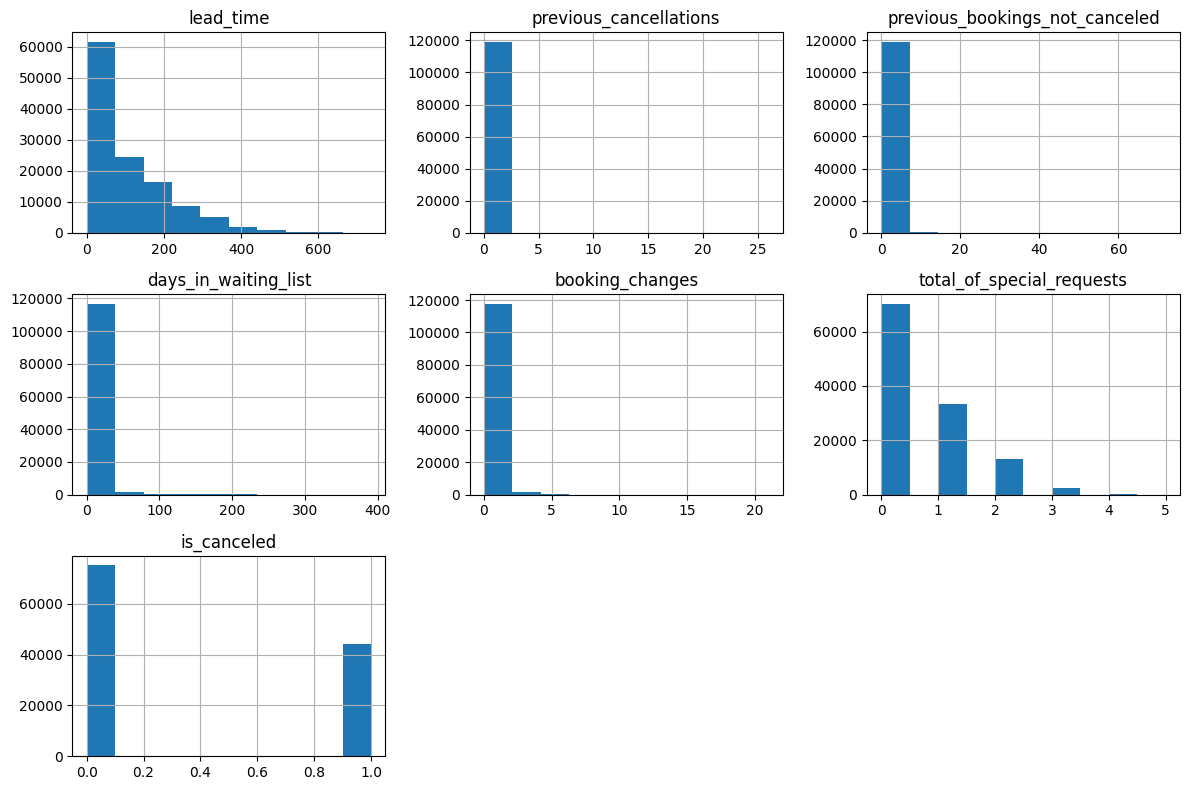

In [31]:
#Create plots (like histograms) to see how your data is distributed
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()
#Most bookings are made 0-180 days in advance, very few book after that
#previous_cancellations: Most customers have no cancellation history
#previous_bookings_not_canceled: Most customers are new 0 previous bookings
#days_in_waiting_list: Almost no one waits in a waiting list
#Most customers don't have special requests But around 35,000 have one or two special requests.
#is_canceled 37% of bookings are canceled



In [28]:
df["is_canceled"].mean() * 100
round((df["is_canceled"].mean() * 100) /100,2) # 37% canceled the booking

np.float64(0.37)

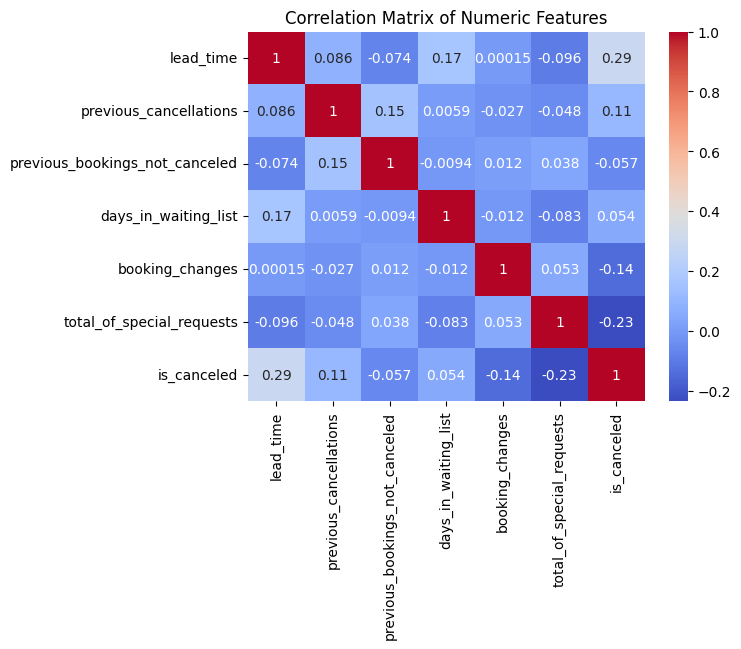

In [38]:
#Analyze correlations
# Select only numeric columns for correlation calculation
df_numeric = df.select_dtypes(include=["number"])

# correlation matrix
correlation_matrix = df_numeric.corr()

# visualize correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [49]:
#Use grouping to compare statistics across different categories.

In [48]:
df.groupby("hotel")["is_canceled"].mean()

,is_canceled
hotel,
City Hotel,0.417270
Resort Hotel,0.277634


In [47]:
df.groupby("market_segment")["is_canceled"].mean()

,is_canceled
market_segment,
Aviation,0.219409
Complementary,0.130552
Corporate,0.187347
Direct,0.153419
Groups,0.610620
Offline TA/TO,0.343160
Online TA,0.367211
Undefined,1.000000


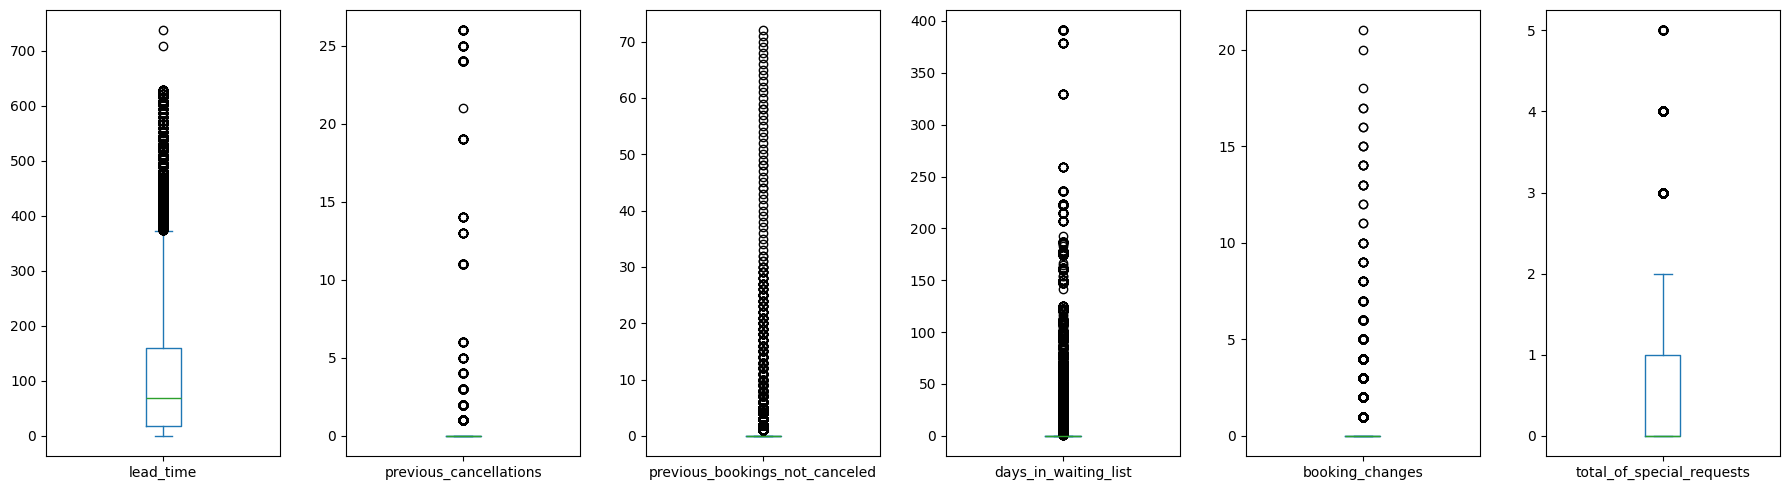

In [57]:
df_numeric = df.select_dtypes(include=["number"]).drop(columns=["is_canceled"])

df_numeric.plot(kind='box', figsize=(18, 5), subplots=True, layout=(1, 6))
plt.tight_layout()
plt.show()


In [58]:
print("""
========================================
         -- Key Insights --
========================================

1. Cancellation Rate:
   - 37% of all bookings are canceled

2. Lead Time:
   - Customers who book earlier tend to cancel more

3. Special Requests:
   - Customers with more special requests cancel less
   - They are more committed to their booking

4. Hotel Type:
   - City Hotel has 41.7% cancellation rate
   - Resort Hotel has 27.7% cancellation rate

5. Market Segment:
   - Groups have the highest cancellation rate (61%)
   - Direct bookings have the lowest (15.3%)

6. Outliers:
   - lead_time: outliers booked 700 days ahead
   - previous_cancellations: outliers canceled 25 times
   - previous_bookings_not_canceled: outliers have 72 completed bookings
   - days_in_waiting_list: outliers waited 391 days
   - booking_changes: outliers changed 21 times
   - total_of_special_requests: max is 5 (not dangerous)

========================================
""")


         -- Key Insights --

1. Cancellation Rate:
   - 37% of all bookings are canceled

2. Lead Time:
   - Customers who book earlier tend to cancel more

3. Special Requests:
   - Customers with more special requests cancel less
   - They are more committed to their booking

4. Hotel Type:
   - City Hotel has 41.7% cancellation rate
   - Resort Hotel has 27.7% cancellation rate

5. Market Segment:
   - Groups have the highest cancellation rate (61%)
   - Direct bookings have the lowest (15.3%)

6. Outliers:
   - lead_time: outliers booked 700 days ahead
   - previous_cancellations: outliers canceled 25 times
   - previous_bookings_not_canceled: outliers have 72 completed bookings
   - days_in_waiting_list: outliers waited 391 days
   - booking_changes: outliers changed 21 times
   - total_of_special_requests: max is 5 (not dangerous)


